In [34]:
import os
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt

import clip
import torch
import transformers
from multilingual_clip import pt_multilingual_clip

In [2]:
DEVICE = "cpu"
IMAGE_DIR = "pics"
IMAGE_MODEL_NAME = "ViT-B/32"
TEXT_MODEL_NAME = "M-CLIP/XLM-Roberta-Large-Vit-B-32"
IMG_EXTENSIONS = (".jpg", ".jpeg", ".png", ".webp", ".bmp")

### Embedder


In [3]:
class MultiEmbedder:
    def __init__(self, text_model_name, img_model_name, device):
        self.text_model = pt_multilingual_clip.MultilingualCLIP.from_pretrained(
            text_model_name
        ).to(device)
        self.tokenizer = transformers.AutoTokenizer.from_pretrained(text_model_name)

        self.img_model, self.img_preprocess = clip.load(img_model_name, device=device)

        self.img_model.eval()
        self.text_model.eval()

    def encode_text(self, text):
        with torch.no_grad():
            text_features = self.text_model.forward([text], tokenizer=self.tokenizer)
            text_features /= text_features.norm(dim=-1, keepdim=True)
        return text_features

    def encode_image(self, img_path):
        image = self.img_preprocess(Image.open(img_path)).unsqueeze(0).to(DEVICE)
        with torch.no_grad():
            img_features = self.img_model.encode_image(image)
            img_features /= img_features.norm(dim=-1, keepdim=True)
        return img_features

In [4]:
embedder = MultiEmbedder(TEXT_MODEL_NAME, IMAGE_MODEL_NAME, DEVICE)

### Image features


In [5]:
def calc_image_features():
    image_paths, image_features = [], []
    for filename in tqdm(os.listdir(IMAGE_DIR)):
        if filename.lower().endswith(IMG_EXTENSIONS):
            path = os.path.join(IMAGE_DIR, filename)
            image_paths.append(path)
            image_features.append(embedder.encode_image(path))

    image_features = torch.cat(image_features, dim=0)
    return image_paths, image_features

In [12]:
image_paths, image_features = calc_image_features()

100%|██████████| 16/16 [00:00<00:00, 23.45it/s]


### Similar images


In [89]:
def calc_similarity(text_features, image_features, image_paths, sort=True):
    similarities = (text_features @ image_features.T).squeeze(0).cpu().numpy()

    scored_images = {
        os.path.basename(path): float(score)
        for path, score in zip(image_paths, similarities)
    }
    if sort:
        return dict(
            sorted(scored_images.items(), key=lambda item: item[1], reverse=True)
        )
    else:
        return scored_images


def find_similar_images(query, topn=5):
    text_features = embedder.encode_text(query)
    img_sim = calc_similarity(text_features, image_features, image_paths)
    return list(img_sim.keys())[:topn], list(img_sim.values())[:topn]

In [90]:
def show_images(imgs, width=15, height=3):
    fig, axes = plt.subplots(1, len(imgs), figsize=(width, height))
    fig.patch.set_visible(False)

    for ax, img in zip(axes, imgs):
        ax.imshow(img, aspect="equal")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

### Demo


In [ ]:
QUERY = "ягоды"

img, sim = find_similar_images(QUERY)
top_images = [Image.open(os.path.join(IMAGE_DIR, i)) for i in img]

for i, s in zip(img, sim):
    print(f"Img: {i}, Score: {s:.3f}")

Img: 13.jpg, Score: 0.243
Img: 2.jpg, Score: 0.227
Img: 15.jpg, Score: 0.209
Img: 9.jpg, Score: 0.190
Img: 4.jpg, Score: 0.186


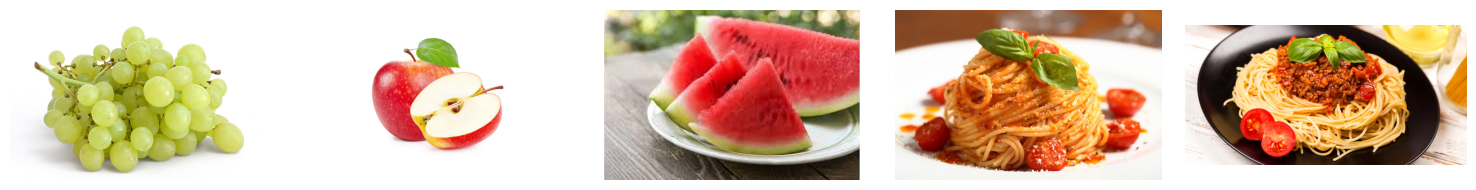

In [95]:
show_images(top_images, width=15, height=2)